## Import Libraries

In [84]:
# Data Handling
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import KNNImputer

# Train Test Split
from sklearn.model_selection import train_test_split

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Imbalanced Data Handling
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import RandomOverSampler
from imblearn.over_sampling import SMOTE, ADASYN

# Hyperparameter Tuning
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import GridSearchCV

# Evaluation Metrics
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

**Intuition:** This cell just brings in all the tools (libraries) we need for loading data, making charts, cleaning data and building models.

## Load Dataset

In [85]:
# Load dataset
df = pd.read_csv("Risk_Alert_Classifier_Dataset_4600.csv")

# Display first five rows
df.head()

,customer_id,age,gender,region,employment_type,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,last_transaction_date,debt_balance_inr,risk_status
0,500001,43.0,Female,NaN,Salaried,82242.0,NaN,0.120,1,2.2,39,33889.0,0,2,4,70,2025-09-26,87273,0
1,500002,29.0,Female,Central,Salaried,32769.0,647.0,0.337,1,1.5,11,10853.0,1,1,1,34,2025-11-24,20600,0
2,500003,36.0,Male,East,Salaried,39731.0,727.0,0.175,0,3.9,45,25519.0,2,1,1,74,2025-09-26,47565,0
3,500004,28.0,Male,North,Unemployed,38990.0,553.0,0.472,7,23.3,103,17806.0,1,2,6,72,2025-10-03,43803,1
4,500005,36.0,Female,East,Self-Employed,41043.0,732.0,0.418,1,9.8,95,27114.0,0,1,1,11,2025-10-26,12008,0


**Intuition:** Here we load our CSV file into a table (DataFrame) and check the first 5 rows to see what the data looks like.

## Basic Dataset Information

In [86]:
print("Shape of Dataset :", df.shape)

df.info()

Shape of Dataset : (4600, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 19 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customer_id                4600 non-null   int64  
 1   age                        4460 non-null   float64
 2   gender                     4600 non-null   object 
 3   region                     4498 non-null   object 
 4   employment_type            4456 non-null   object 
 5   annual_income_inr          4434 non-null   float64
 6   credit_score               4384 non-null   float64
 7   credit_utilization_ratio   4453 non-null   float64
 8   missed_payments_12m        4600 non-null   int64  
 9   avg_late_payment_days      4600 non-null   float64
 10  monthly_transaction_count  4600 non-null   int64  
 11  monthly_spend_inr          4471 non-null   float64
 12  cash_advance_count_6m      4600 non-null   int64  
 13  complaints_last_6m

**Intuition:** This shows how many rows and columns we have, and basic info like data type of each column.

## Statistical Summary

In [87]:
df.describe()

,customer_id,age,annual_income_inr,credit_score,credit_utilization_ratio,missed_payments_12m,avg_late_payment_days,monthly_transaction_count,monthly_spend_inr,cash_advance_count_6m,complaints_last_6m,failed_login_attempts_3m,account_tenure_months,debt_balance_inr,risk_status
count,4600.000000,4460.000000,4434.000000,4384.000000,4453.000000,4600.000000,4600.000000,4600.000000,4471.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,502300.500000,36.360314,41753.518268,677.784443,0.394721,0.924130,5.538696,65.030000,21511.273541,0.709783,0.443478,2.087174,53.744565,41143.328696,0.121087
std,1328.049949,10.670375,17740.750972,64.888787,0.205771,1.300018,5.624891,24.180762,10887.272864,1.020507,0.716546,1.621504,31.325334,26665.221097,0.326264
min,500001.000000,18.000000,15000.000000,405.000000,0.002000,0.000000,0.100000,5.000000,3769.000000,0.000000,0.000000,0.000000,2.000000,3653.000000,0.000000
25%,501150.750000,28.000000,28980.000000,638.000000,0.232000,0.000000,2.100000,49.000000,13422.500000,0.000000,0.000000,1.000000,31.000000,21302.750000,0.000000
50%,502300.500000,36.000000,38932.500000,682.000000,0.370000,1.000000,3.900000,65.000000,19317.000000,0.000000,0.000000,2.000000,48.000000,35638.500000,0.000000
75%,503450.250000,44.000000,51282.500000,721.250000,0.531000,1.000000,6.600000,81.000000,27147.000000,1.000000,1.000000,3.000000,70.000000,54274.250000,0.000000
max,504600.000000,75.000000,163002.000000,850.000000,0.978000,10.000000,47.100000,153.000000,87389.000000,7.000000,7.000000,12.000000,180.000000,213601.000000,1.000000


**Intuition:** This gives simple stats like average, min and max for number columns, so we understand the data better.

## Check Missing Values

In [88]:
df.isnull().sum()

customer_id                    0
age                          140
gender                         0
region                       102
employment_type              144
annual_income_inr            166
credit_score                 216
credit_utilization_ratio     147
missed_payments_12m            0
avg_late_payment_days          0
monthly_transaction_count      0
monthly_spend_inr            129
cash_advance_count_6m          0
complaints_last_6m             0
failed_login_attempts_3m       0
account_tenure_months          0
last_transaction_date          0
debt_balance_inr               0
risk_status                    0
dtype: int64

**Intuition:** This checks how many empty (missing) values are present in each column.

## Duplicate Value

In [89]:
df.duplicated().sum()

0

**Intuition:** This counts how many rows are exact duplicates in our data.

# Remove Duplicate Records

In [90]:
df.drop_duplicates(inplace=True)

print("New Shape :", df.shape)

New Shape : (4600, 19)


**Intuition:** Here we remove duplicate rows so every row in our data is unique.

# Target Variable Distribution

In [91]:
risk_dist = df["risk_status"].value_counts()

risk_dist

risk_status
0    4043
1     557
Name: count, dtype: int64

**Intuition:** This shows how many rows belong to each risk category, so we know the class counts.

# Numerical Feature Distribution

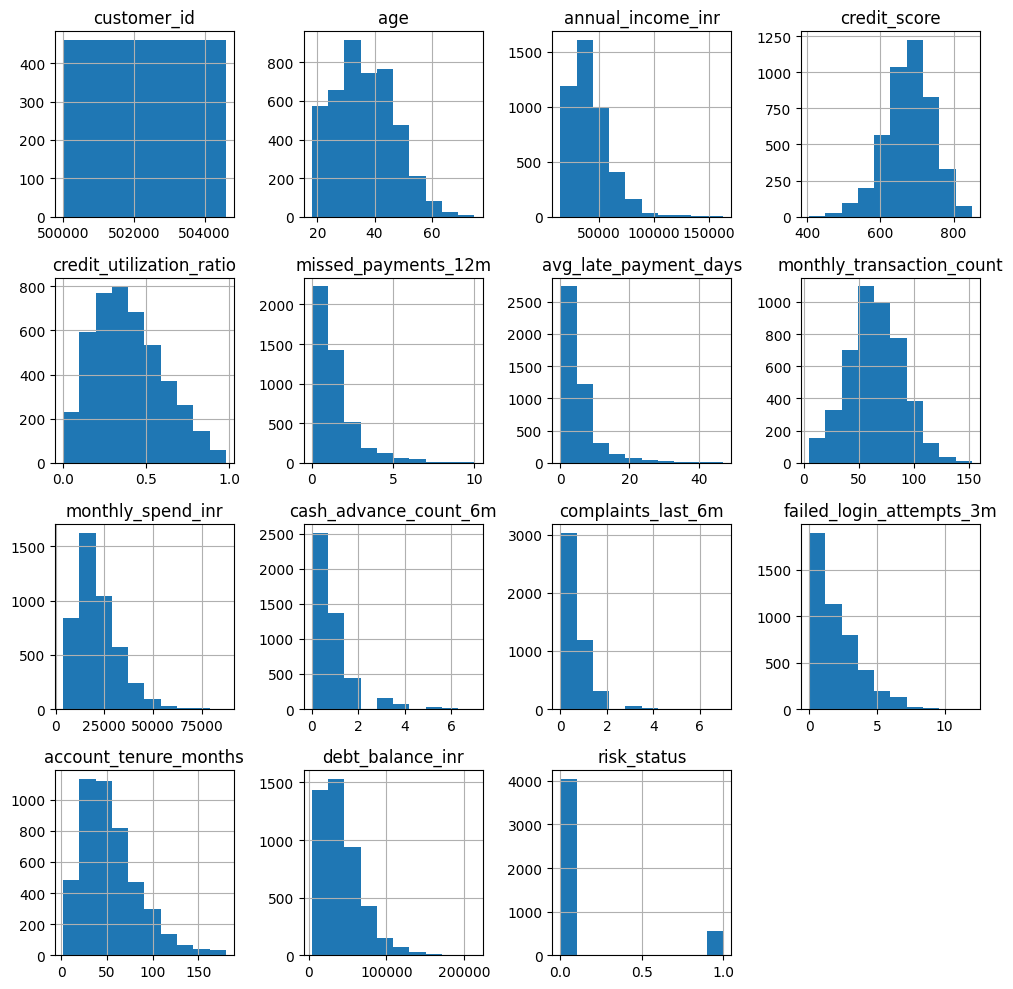

In [92]:
df.hist(
    figsize=(10, 10),
)

# Adjust spacing between plots
plt.tight_layout()

# Display the figure
plt.show()

**Intuition:** This plots histograms for every number column to see how the values are spread out.

# Correlation Analysis

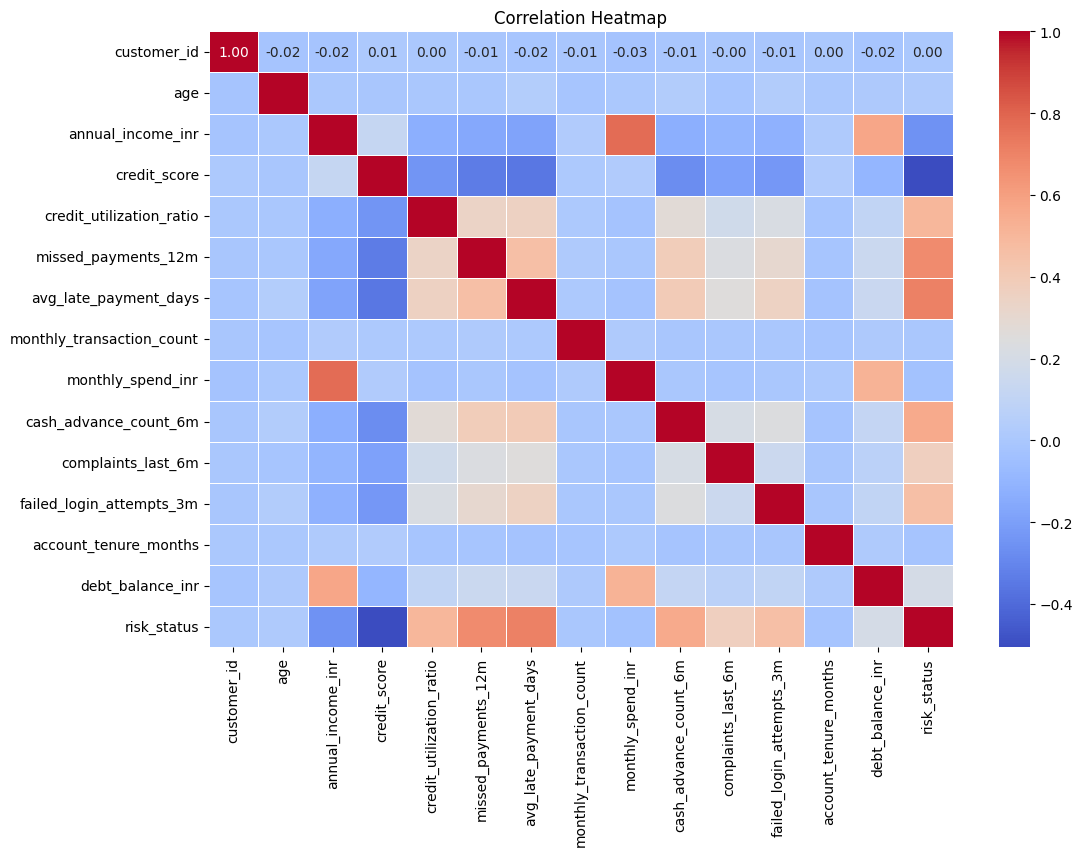

In [93]:
# Select only numerical columns
numeric_features = df.select_dtypes(include=["number"])

# Calculate the correlation matrix
correlation_matrix = numeric_features.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

**Intuition:** This heatmap shows how strongly each number column is related to the others.

# Encoding Categorical Features

In [94]:
# Create a separate copy of the dataset
processed_data = df.copy()

# Find all categorical columns
categorical_features = processed_data.select_dtypes(include=["object"]).columns

# Convert each categorical column into numerical values
for feature in categorical_features:
    encoder = LabelEncoder()
    processed_data[feature] = encoder.fit_transform(processed_data[feature].astype(str))

**Intuition:** Here text columns are turned into numbers, since ML models only understand numbers.

# Handling Missing Values using KNN Imputer

In [95]:
# Initialize the KNN Imputer
knn_imputer = KNNImputer(n_neighbors=5)

# Fill missing values and create a new DataFrame
processed_data = pd.DataFrame(
    knn_imputer.fit_transform(processed_data),
    columns=processed_data.columns,
    index=processed_data.index
)

**Intuition:** This fills the missing values by looking at similar nearby rows (KNN).

# Dataset Understanding & Preparation
## Identify Input Features and Target Variable

In [96]:
X = processed_data.drop('risk_status', axis=1)

y = processed_data['risk_status']

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (4600, 18)
Target Shape : (4600,)


**Intuition:** Here we separate input features (X) from the target column (y) we want to predict.

# Perform Train-Test Split

In [97]:
# Split the dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shape of each dataset
print(f"Training Data Shape : {X_train.shape}")
print(f"Testing Data Shape  : {X_test.shape}")

Training Data Shape : (3680, 18)
Testing Data Shape  : (920, 18)


**Intuition:** This splits the data into training and testing parts, so we can train on one and check on the other.

# Verify Missing Values after KNN Imputation

In [98]:
df_model.isnull().sum()

customer_id                  0
age                          0
gender                       0
region                       0
employment_type              0
annual_income_inr            0
credit_score                 0
credit_utilization_ratio     0
missed_payments_12m          0
avg_late_payment_days        0
monthly_transaction_count    0
monthly_spend_inr            0
cash_advance_count_6m        0
complaints_last_6m           0
failed_login_attempts_3m     0
account_tenure_months        0
last_transaction_date        0
debt_balance_inr             0
risk_status                  0
dtype: int64

**Intuition:** This checks again that no missing values are left after filling them.

# Baseline Classification Model
## Implement Logistic Regression Model

In [99]:
# Create the Logistic Regression model
logistic_model = LogisticRegression(max_iter=1000)

# Train the model using the training data
logistic_model.fit(X_train, y_train)

# Predict the target values for the test dataset
lr_predictions = logistic_model.predict(X_test)

print("Logistic Regression model has been trained successfully.")

Logistic Regression model has been trained successfully.


**Intuition:** Here we train a simple Logistic Regression model on the training data to predict risk.

# Generate Confusion Matrix

In [100]:
lr_predictions = logistic_model.predict(X_test)
# Generate the confusion matrix
cm_lr = confusion_matrix(y_test, lr_predictions)

# Display the confusion matrix
print("Confusion Matrix:\n")
print(cm_lr)

Confusion Matrix:

[[805   4]
 [  6 105]]


**Intuition:** This builds a confusion matrix to see how many predictions were right and wrong.

# Visualize Confusion Matrix

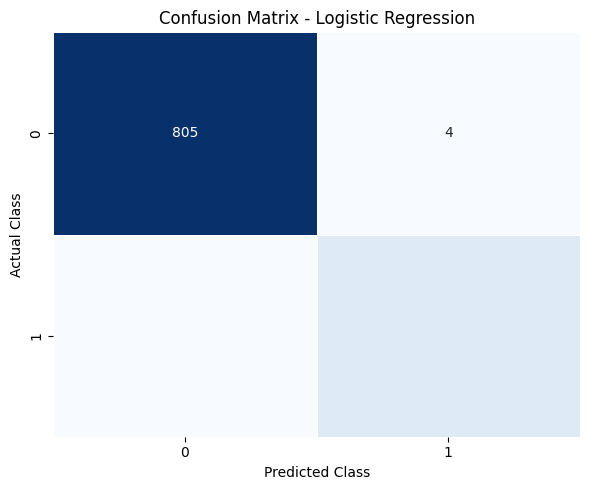

In [101]:
# Display the confusion matrix as a heatmap

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    cbar=False
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

**Intuition:** This draws the confusion matrix as a heatmap so it's easier to read.

## Calculate Performance Metrics

In [102]:
# Predict on the test data
y_pred_lr = lr_model.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)

print("Accuracy " , accuracy_lr)
print("Precision ", precision_lr)
print("Recall   " , recall_lr)
print("F1 Score " , f1_lr)

Accuracy  0.9891304347826086
Precision  0.963302752293578
Recall    0.9459459459459459
F1 Score  0.9545454545454546


**Intuition:** Here we calculate accuracy, precision, recall and F1 score to check how good the model is.

# Classification Report

In [103]:
# Generate the classification report

lr_report = classification_report(y_test, y_pred_lr)

# Display the report
print("Classification Report:\n")
print(lr_report)

Classification Report:

              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99       809
         1.0       0.96      0.95      0.95       111

    accuracy                           0.99       920
   macro avg       0.98      0.97      0.97       920
weighted avg       0.99      0.99      0.99       920



**Intuition:** This prints a full report showing precision, recall and F1 score for each class.

# Identify Type-I and Type-II Errors

In [104]:
# Extract the four values from the confusion matrix

tn, fp, fn, tp = cm_lr.ravel()

# Display each value separately
print("True Negatives :", tn)
print("False Positives :", fp)
print("False Negatives :", fn)
print("True Positives :", tp)

True Negatives : 805
False Positives : 4
False Negatives : 6
True Positives : 105


**Intuition:** This pulls out the 4 values from the confusion matrix: true and false positives and negatives.

# Understanding Type-I Error & Type-II

In [105]:
# Display Type-I and Type-II classification errors

print("Type-I Error (False Positive) " , fp)
print("Type-II Error (False Negative) " , fn)

Type-I Error (False Positive)  4
Type-II Error (False Negative)  6


**Intuition:** This shows Type-I error (false alarm) and Type-II error (missed alarm) separately.

# Baseline Model Summary

In [106]:
# Store the evaluation metrics in a DataFrame

baseline_results = pd.DataFrame({
    "Evaluation Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ],
    "Score": [
        accuracy_lr,
        precision_lr,
        recall_lr,
        f1_lr
    ]
})

# Display the summary table
baseline_results

,Evaluation Metric,Score
0,Accuracy,0.989130
1,Precision,0.963303
2,Recall,0.945946
3,F1-Score,0.954545


**Intuition:** This puts all baseline model scores into one small table for easy comparison.

# Handling Imbalanced Data
## Demonstrate the Impact of Class Imbalance on Model Performance

In [107]:
# Check the number of samples available in each class

class_distribution = y_train.value_counts()

print("Class Distribution Before Balancing:\n")
print(class_distribution)

Class Distribution Before Balancing:

risk_status
0.0    3234
1.0     446
Name: count, dtype: int64


**Intuition:** This checks how many samples each class has in training data, before balancing.

# Visualize Class Distribution

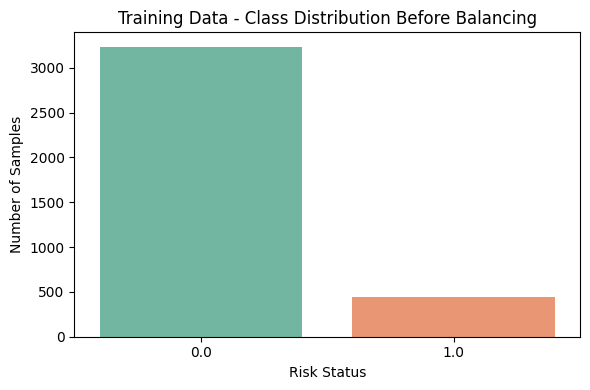

In [108]:
# Visualize the distribution of target classes before balancing

plt.figure(figsize=(6, 4))

sns.countplot(
    x=y_train,
    palette="Set2"
)

plt.title("Training Data - Class Distribution Before Balancing")
plt.xlabel("Risk Status")
plt.ylabel("Number of Samples")

plt.tight_layout()
plt.show()

**Intuition:** This draws a bar chart to show the class imbalance before balancing.

# Apply Random Under Sampling

In [109]:
# Initialize the Random Under Sampler
under_sampler = RandomUnderSampler(random_state=42)

# Apply under sampling on the training dataset
X_under, y_under = under_sampler.fit_resample(X_train, y_train)

# Check the updated class distribution
balanced_classes = y_under.value_counts()

print("Class Distribution After Random Under Sampling:\n")
print(balanced_classes)

Class Distribution After Random Under Sampling:

risk_status
0.0    446
1.0    446
Name: count, dtype: int64


**Intuition:** Here we reduce the bigger class to match the smaller one, this is called under sampling.

# Train Logistic Regression on Under Sampled Data

In [110]:
# Initialize the Logistic Regression classifier
lr_under = LogisticRegression(max_iter=1000)

# Train the classifier using the under-sampled training data
lr_under.fit(X_under, y_under)

# Predict the class labels for the testing dataset
y_pred_under = lr_under.predict(X_test)

print("Model training completed successfully.")

Model training completed successfully.


**Intuition:** This trains Logistic Regression again, but now on the under-sampled (balanced) data.

# Evaluate Under Sampling

In [111]:
accuracy_under = accuracy_score(y_test, y_pred_under)
precision_under = precision_score(y_test, y_pred_under)
recall_under = recall_score(y_test, y_pred_under)
f1_under = f1_score(y_test, y_pred_under)

print("Accuracy :", accuracy_under)
print("Precision :", precision_under)
print("Recall :", recall_under)
print("F1 Score :", f1_under)

Accuracy : 0.9847826086956522
Precision : 0.8943089430894309
Recall : 0.990990990990991
F1 Score : 0.9401709401709402


**Intuition:** This checks accuracy, precision, recall and F1 score after under sampling.

# Apply Random Over Sampling

In [112]:
# Initialize oversampler
over_sampler = RandomOverSampler(random_state=42)

# Apply oversampling on training data
X_over, y_over = over_sampler.fit_resample(X_train, y_train)

# Display class distribution after oversampling
print("Class Distribution After Oversampling:\n")
print(y_over.value_counts())

Class Distribution After Oversampling:

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


**Intuition:** Here we increase the smaller class by repeating its samples, this is called over sampling.

# Train Logistic Regression on Over Sampled Data

In [113]:
# Initialize Logistic Regression model
lr_over = LogisticRegression(max_iter=1000)

# Train model on oversampled data
lr_over.fit(X_over, y_over)

# Predict on test data
y_pred_over = lr_over.predict(X_test)

**Intuition:** This trains Logistic Regression on the over-sampled data.

# Evaluate Over Sampling

In [114]:
# Calculate evaluation metrics for oversampled model
accuracy_over = accuracy_score(y_test, y_pred_over)
precision_over = precision_score(y_test, y_pred_over)
recall_over = recall_score(y_test, y_pred_over)
f1_over = f1_score(y_test, y_pred_over)

# Print results
print("Accuracy  :", accuracy_over)
print("Precision :", precision_over)
print("Recall    :", recall_over)
print("F1 Score  :", f1_over)

Accuracy  : 0.9793478260869565
Precision : 0.859375
Recall    : 0.990990990990991
F1 Score  : 0.9205020920502092


**Intuition:** This checks the model's performance after over sampling.

# Apply SMOTE

In [115]:
# Initialize the SMOTE sampler
smote = SMOTE(random_state=42)

# Generate a balanced training dataset using SMOTE
X_smote, y_smote = smote.fit_resample(X_train, y_train)

# Display the updated class distribution
smote_distribution = y_smote.value_counts()

print("Class Distribution After SMOTE:\n")
print(smote_distribution)

Class Distribution After SMOTE:

risk_status
0.0    3234
1.0    3234
Name: count, dtype: int64


**Intuition:** SMOTE creates new synthetic samples for the smaller class instead of just repeating old ones.

# Train Logistic Regression using SMOTE Data

In [116]:
# Initialize the Logistic Regression model
lr_smote = LogisticRegression(max_iter=1000)

# Train the model using the SMOTE-balanced training data
lr_smote.fit(X_smote, y_smote)

# Predict the target labels for the test dataset
y_pred_smote = lr_smote.predict(X_test)

print("Logistic Regression model trained successfully using the SMOTE-balanced dataset.")

Logistic Regression model trained successfully using the SMOTE-balanced dataset.


**Intuition:** This trains Logistic Regression on the SMOTE balanced data.

# Evaluate SMOTE

In [117]:
# Calculate the evaluation metrics for the SMOTE-based model

accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

# Display the evaluation results
print("Accuracy"  , accuracy_smote)
print("Precision" , precision_smote)
print("Recall"    , recall_smote)
print("F1-Score " , f1_smote)

Accuracy 0.9880434782608696
Precision 0.923728813559322
Recall 0.9819819819819819
F1-Score  0.9519650655021834


**Intuition:** This checks the model's performance after using SMOTE.

# Apply ADASYN

In [118]:
# Initialize the ADASYN sampler
adasyn = ADASYN(random_state=42)

# Apply ADASYN to balance the training dataset
X_ada, y_ada = adasyn.fit_resample(X_train, y_train)

# Display the class distribution after balancing
adasyn_distribution = y_ada.value_counts()

print("Class Distribution After ADASYN:\n")
print(adasyn_distribution)

Class Distribution After ADASYN:

risk_status
0.0    3234
1.0    3220
Name: count, dtype: int64


**Intuition:** ADASYN is similar to SMOTE but adds more samples where the model finds it harder to learn.

# Train Logistic Regression using ADASYN Data

In [119]:
# Initialize the Logistic Regression model
lr_ada = LogisticRegression(max_iter=1000)

# Train the model using the ADASYN-balanced dataset
lr_ada.fit(X_ada, y_ada)

# Generate predictions for the testing dataset
y_pred_ada = lr_ada.predict(X_test)

print("Logistic Regression model trained successfully on the ADASYN-balanced dataset.")

Logistic Regression model trained successfully on the ADASYN-balanced dataset.


**Intuition:** This trains Logistic Regression on the ADASYN balanced data.

# Evaluate ADASYN

In [120]:
accuracy_ada = accuracy_score(y_test, y_pred_ada)
precision_ada = precision_score(y_test, y_pred_ada)
recall_ada = recall_score(y_test, y_pred_ada)
f1_ada = f1_score(y_test, y_pred_ada)

print("Accuracy :", accuracy_ada)
print("Precision :", precision_ada)
print("Recall :", recall_ada)
print("F1 Score :", f1_ada)

Accuracy : 0.9782608695652174
Precision : 0.864
Recall : 0.972972972972973
F1 Score : 0.9152542372881356


**Intuition:** This checks the model's performance after using ADASYN.

# Compare All Balancing Techniques

In [121]:
# Create a summary table to compare all sampling techniques

results = pd.DataFrame({
    "Sampling Method": [
        "Original Data",
        "Random Under Sampling",
        "Random Over Sampling",
        "SMOTE",
        "ADASYN"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_under,
        accuracy_over,
        accuracy_smote,
        accuracy_ada
    ],
    "Precision": [
        precision_lr,
        precision_under,
        precision_over,
        precision_smote,
        precision_ada
    ],
    "Recall": [
        recall_lr,
        recall_under,
        recall_over,
        recall_smote,
        recall_ada
    ],
    "F1-Score": [
        f1_lr,
        f1_under,
        f1_over,
        f1_smote,
        f1_ada
    ]
})

# Display the comparison table
results

,Sampling Method,Accuracy,Precision,Recall,F1-Score
0,Original Data,0.989130,0.963303,0.945946,0.954545
1,Random Under Sampling,0.984783,0.894309,0.990991,0.940171
2,Random Over Sampling,0.979348,0.859375,0.990991,0.920502
3,SMOTE,0.988043,0.923729,0.981982,0.951965
4,ADASYN,0.978261,0.864000,0.972973,0.915254


**Intuition:** This table compares all balancing methods side by side so we can pick the best one.

# Tree-Based Classification Models
## Train a Decision Tree Classifier

In [122]:
dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

y_pred_dt = dt_model.predict(X_test)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


**Intuition:** Here we train a Decision Tree model, which makes decisions by splitting data step by step.

# Evaluate Decision Tree Model

In [123]:
# Calculate the performance metrics for the Decision Tree model

accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

# Display the evaluation results
print(f"Accuracy  : {accuracy_dt:.4f}")
print(f"Precision : {precision_dt:.4f}")
print(f"Recall    : {recall_dt:.4f}")
print(f"F1-Score  : {f1_dt:.4f}")

Accuracy  : 0.9728
Precision : 0.8909
Recall    : 0.8829
F1-Score  : 0.8869


**Intuition:** This checks accuracy, precision, recall and F1 score for the Decision Tree model.

# Confusion Matrix for Decision Tree

In [124]:
cm_dt = confusion_matrix(y_test, y_pred_dt)

print(cm_dt)

[[797  12]
 [ 13  98]]


**Intuition:** This builds the confusion matrix for the Decision Tree model.

# Visualize Confusion Matrix

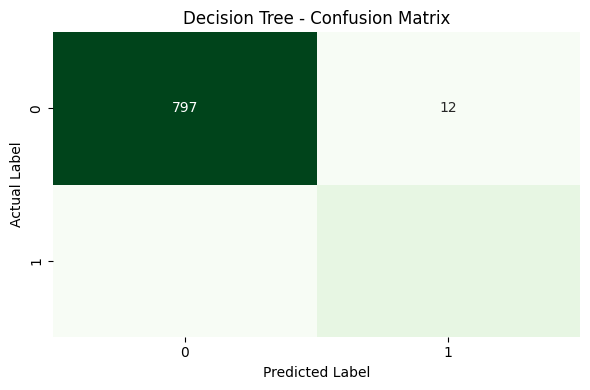

In [125]:
# Visualize the confusion matrix for the Decision Tree model

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm_dt,
    annot=True,
    fmt="d",
    cmap="Greens",
    cbar=False
)

plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

**Intuition:** This draws the Decision Tree confusion matrix as a heatmap.

# Train a Random Forest Classifier

In [126]:
# Initialize the Random Forest classifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the training dataset
rf_model.fit(X_train, y_train)

# Predict the target labels for the test dataset
y_pred_rf = rf_model.predict(X_test)

print("Random Forest model has been trained successfully.")

Random Forest model has been trained successfully.


**Intuition:** Here we train a Random Forest model, which combines many decision trees for better results.

# Evaluate Random Forest Model

In [128]:
# Calculate model evaluation metrics

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Accuracy  :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall    :", recall_rf)
print("F1 Score  :", f1_rf)

Accuracy  : 0.9978260869565218
Precision : 0.990990990990991
Recall    : 0.990990990990991
F1 Score  : 0.990990990990991


**Intuition:** This checks accuracy, precision, recall and F1 score for the Random Forest model.

# Confusion Matrix for Random Forest

In [129]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

print(cm_rf)

[[808   1]
 [  1 110]]


**Intuition:** This builds the confusion matrix for the Random Forest model.

# Visualize Confusion Matrix

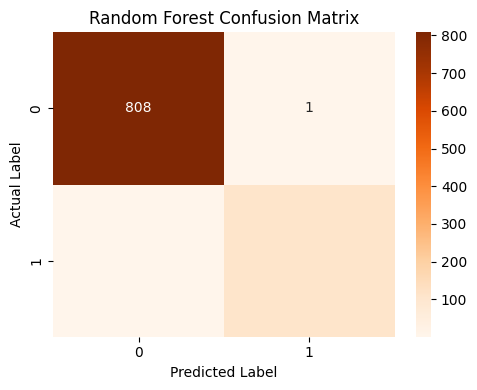

In [130]:
# Display the confusion matrix of the Random Forest model

plt.figure(figsize=(5, 4))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.tight_layout()
plt.show()

**Intuition:** This draws the Random Forest confusion matrix as a heatmap.

# Compare All Models

In [131]:
# Create a comparison table for all classification models

model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf
    ],
    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf
    ]
})

# Display the comparison table
model_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.989130,0.963303,0.945946,0.954545
1,Decision Tree,0.972826,0.890909,0.882883,0.886878
2,Random Forest,0.997826,0.990991,0.990991,0.990991


**Intuition:** This table compares Logistic Regression, Decision Tree and Random Forest together.

# Check for Overfitting

In [132]:
# Evaluate the Decision Tree model
print("Decision Tree Training Accuracy :", dt_model.score(X_train, y_train))
print("Decision Tree Testing Accuracy  :", dt_model.score(X_test, y_test))

print("-" * 50)

# Evaluate the Random Forest model
print("Random Forest Training Accuracy :", rf_model.score(X_train, y_train))
print("Random Forest Testing Accuracy  :", rf_model.score(X_test, y_test))

Decision Tree Training Accuracy : 1.0
Decision Tree Testing Accuracy  : 0.9728260869565217
--------------------------------------------------
Random Forest Training Accuracy : 1.0
Random Forest Testing Accuracy  : 0.9978260869565218


**Intuition:** This compares training vs testing accuracy to check if the model is overfitting.

# Hyperparameter Tuning
## Hyperparameter Tuning using RandomizedSearchCV

In [139]:
# Define the hyperparameter search space
random_params = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [None, 5, 10, 15, 20],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

# Initialize Randomized Search CV
random_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=random_params,
    n_iter=10,
    cv=5,
    scoring="f1",
    random_state=42,
    n_jobs=-1
)
print("Randomized Search completed successfully.")
# Train the model
random_search.fit(X_train, y_train)

Randomized Search completed successfully.


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'max_depth': [None, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versi

**Intuition:** This tries many random combinations of settings to find a good Random Forest model.

# Best Parameters from RandomizedSearchCV

In [140]:
print("Best Parameters:")
print(random_search.best_params_)

Best Parameters:
{'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 15}


**Intuition:** This prints the best settings found by Randomized Search.

# Evaluate RandomizedSearchCV Model

In [141]:
# Retrieve the best Random Forest model
best_rf_random = random_search.best_estimator_

# Predict the test dataset
y_pred_random = best_rf_random.predict(X_test)

# Calculate evaluation metrics
accuracy_random = accuracy_score(y_test, y_pred_random)
precision_random = precision_score(y_test, y_pred_random)
recall_random = recall_score(y_test, y_pred_random)
f1_random = f1_score(y_test, y_pred_random)

# Display the model performance
print("Accuracy  :", accuracy_random)
print("Precision :", precision_random)
print("Recall    :", recall_random)
print("F1 Score  :", f1_random)

Accuracy  : 0.9967391304347826
Precision : 1.0
Recall    : 0.972972972972973
F1 Score  : 0.9863013698630136


**Intuition:** This checks how well the best model from Randomized Search performs.

# Hyperparameter Tuning using GridSearchCV

In [143]:
# Define the parameter grid for Grid Search
grid_params = {
    "n_estimators": [100, 150],
    "max_depth": [10, 15],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

# Initialize the Grid Search object
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=grid_params,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
print("Grid Search completed successfully.")
# Train the Grid Search model
grid_search.fit(X_train, y_train)

Grid Search completed successfully.


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 15], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 150]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is d

**Intuition:** This checks every combination of settings in a fixed list to find the best Random Forest model.

# Best Parameters from GridSearchCV

In [144]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 150}


**Intuition:** This prints the best settings found by Grid Search.

# Evaluate GridSearchCV Model

In [145]:
# Retrieve the best model obtained from Grid Search
best_rf_grid = grid_search.best_estimator_

# Generate predictions on the testing dataset
y_pred_grid = best_rf_grid.predict(X_test)

# Calculate the evaluation metrics
accuracy_grid = accuracy_score(y_test, y_pred_grid)
precision_grid = precision_score(y_test, y_pred_grid)
recall_grid = recall_score(y_test, y_pred_grid)
f1_grid = f1_score(y_test, y_pred_grid)

# Display the evaluation results
print("Accuracy  :", accuracy_grid)
print("Precision :", precision_grid)
print("Recall    :", recall_grid)
print("F1 Score  :", f1_grid)

Accuracy  : 0.9989130434782608
Precision : 1.0
Recall    : 0.990990990990991
F1 Score  : 0.995475113122172


**Intuition:** This checks how well the best model from Grid Search performs.

# Compare Untuned and Tuned Models

In [146]:
# Create a summary table for all Random Forest models

tuning_results = pd.DataFrame({
    "Model": [
        "Random Forest",
        "Randomized Search CV",
        "Grid Search CV"
    ],
    "Accuracy": [
        accuracy_rf,
        accuracy_random,
        accuracy_grid
    ],
    "Precision": [
        precision_rf,
        precision_random,
        precision_grid
    ],
    "Recall": [
        recall_rf,
        recall_random,
        recall_grid
    ],
    "F1 Score": [
        f1_rf,
        f1_random,
        f1_grid
    ]
})

# Display the comparison table
tuning_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.997826,0.990991,0.990991,0.990991
1,Randomized Search CV,0.996739,1.000000,0.972973,0.986301
2,Grid Search CV,0.998913,1.000000,0.990991,0.995475


**Intuition:** This table compares the normal Random Forest with its tuned versions.

# ROC Curve, AUC Score and Final Model Selection
## Calculate ROC Curve

In [147]:
# Predict probability for the positive class
y_prob = best_rf_grid.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

**Intuition:** This calculates points for the ROC curve, showing the trade-off between catching risks and false alarms.

# Plot ROC Curve

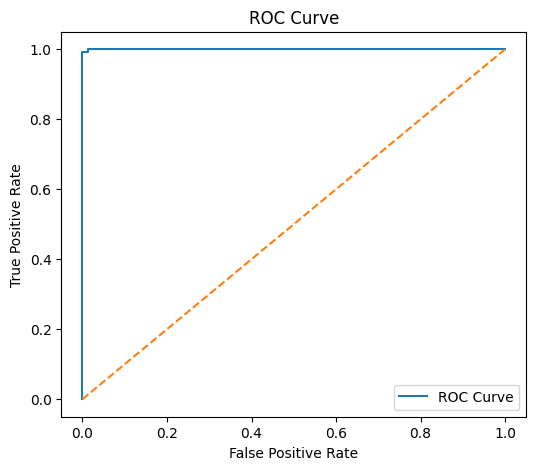

In [148]:
plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

**Intuition:** This draws the ROC curve so we can see the model's performance visually.

# Calculate AUC Score


In [150]:
# Calculate the Area Under the ROC Curve (AUC)

auc_score = roc_auc_score(y_test, y_prob)

# Display the AUC score
print("AUC Score :", auc_score)

AUC Score : 0.9998886401853027


**Intuition:** This calculates the AUC score, one number that tells how good the model is overall.

# Compare All Models

In [151]:
final_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "RandomizedSearchCV",
        "GridSearchCV"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_dt,
        accuracy_rf,
        accuracy_random,
        accuracy_grid
    ],
    "Precision": [
        precision_lr,
        precision_dt,
        precision_rf,
        precision_random,
        precision_grid
    ],
    "Recall": [
        recall_lr,
        recall_dt,
        recall_rf,
        recall_random,
        recall_grid
    ],
    "F1 Score": [
        f1_lr,
        f1_dt,
        f1_rf,
        f1_random,
        f1_grid
    ]
})

final_results

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.989130,0.963303,0.945946,0.954545
1,Decision Tree,0.972826,0.890909,0.882883,0.886878
2,Random Forest,0.997826,0.990991,0.990991,0.990991
3,RandomizedSearchCV,0.996739,1.000000,0.972973,0.986301
4,GridSearchCV,0.998913,1.000000,0.990991,0.995475


**Intuition:** This table brings together the scores of all models we tried, for a final comparison.

# Display the Best Model

In [152]:
best_model = final_results.sort_values(
    by="F1 Score",
    ascending=False
)

print(best_model.head(1))

          Model  Accuracy  Precision    Recall  F1 Score
4  GridSearchCV  0.998913        1.0  0.990991  0.995475


**Intuition:** This picks and shows the single best model based on the highest F1 score.